# Kerala Ward Shapefile Visualization

This notebook demonstrates how to visualize the ward shapefiles generated from the Kerala ward data conversion process.

## Overview
- Load and explore shapefiles using geopandas
- Visualize ward boundaries with matplotlib
- Compare different districts
- Interactive exploration of ward data

In [1]:
# Install required packages if not already installed
%pip install geopandas matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import pandas as pd

# Set matplotlib to display plots inline
%matplotlib inline

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Explore available shapefiles
shapefiles_dir = Path("./shapefiles")

print("Shapefiles directory:", shapefiles_dir.absolute())
print("Exists:", shapefiles_dir.exists())

if shapefiles_dir.exists():
    districts = [d for d in shapefiles_dir.iterdir() if d.is_dir()]
    districts.sort()
    
    print(f"\nFound {len(districts)} districts:")
    for district in districts:
        shp_files = list(district.glob("*.shp"))
        print(f"  - {district.name}: {len(shp_files)} shapefile(s)")
        
    # Store districts list for later use
    available_districts = [d.name for d in districts]
else:
    print("Shapefiles directory not found!")
    available_districts = []

Shapefiles directory: /home/kailas/projects/Kerala_Ward_files/shapefiles
Exists: True

Found 14 districts:
  - Alappuzha: 1 shapefile(s)
  - Ernakulam: 1 shapefile(s)
  - Idukki: 1 shapefile(s)
  - Kannur: 1 shapefile(s)
  - Kasaragod: 1 shapefile(s)
  - Kollam: 1 shapefile(s)
  - Kottayam: 1 shapefile(s)
  - Kozhikode: 1 shapefile(s)
  - Malappuram: 1 shapefile(s)
  - Palakkad: 1 shapefile(s)
  - Pathanamthitta: 1 shapefile(s)
  - Thiruvanathapuram: 1 shapefile(s)
  - Thrissur: 1 shapefile(s)
  - Wayanad: 1 shapefile(s)


In [3]:
def visualize_shapefile(district_name, figsize=(12, 8)):
    """
    Visualize shapefile for a given district.
    
    Parameters:
    district_name (str): Name of the district
    figsize (tuple): Figure size for the plot
    """
    shp_path = shapefiles_dir / district_name / f"{district_name}.shp"
    
    if not shp_path.exists():
        print(f"Shapefile not found: {shp_path}")
        return None
    
    print(f"Loading {shp_path}...")
    
    try:
        # Load the shapefile
        gdf = gpd.read_file(shp_path)
        
        print(f"✓ Loaded {len(gdf)} features")
        print(f"  CRS: {gdf.crs}")
        print(f"  Columns: {list(gdf.columns)}")
        print(f"  Geometry type: {gdf.geometry.type.iloc[0] if len(gdf) > 0 else 'None'}")
        
        # Display first few rows
        print("\nFirst 5 rows:")
        display(gdf.head())
        
        # Create the plot
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # Plot the shapefile
        gdf.plot(ax=ax, 
                color='lightblue', 
                edgecolor='black', 
                alpha=0.7,
                linewidth=0.5)
        
        # Add title and labels
        ax.set_title(f'Ward Boundaries - {district_name}', fontsize=16, pad=20)
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Add info text
        info_text = f'Features: {len(gdf)}\nCRS: {gdf.crs}'
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        return gdf
        
    except Exception as e:
        print(f"Error visualizing {shp_path}: {e}")
        return None

Visualizing sample district: Alappuzha
Loading shapefiles/Alappuzha/Alappuzha.shp...
✓ Loaded 78 features
  CRS: EPSG:4326
  Columns: ['name', 'district', 'html_page', 'id', 'geometry']
  Geometry type: Point

First 5 rows:


,name,district,html_page,id,geometry
0,Alappuzha,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Al...,1,POINT (76.1355 6.2981)
1,Ala,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Al...,2,POINT (76.1855 6.2981)
2,Ambalapuzha North,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Am...,3,POINT (76.2355 6.2981)
3,Ambalapuzha South,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Am...,4,POINT (76.2855 6.2981)
4,Arattupuzha,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Ar...,5,POINT (76.3355 6.2981)


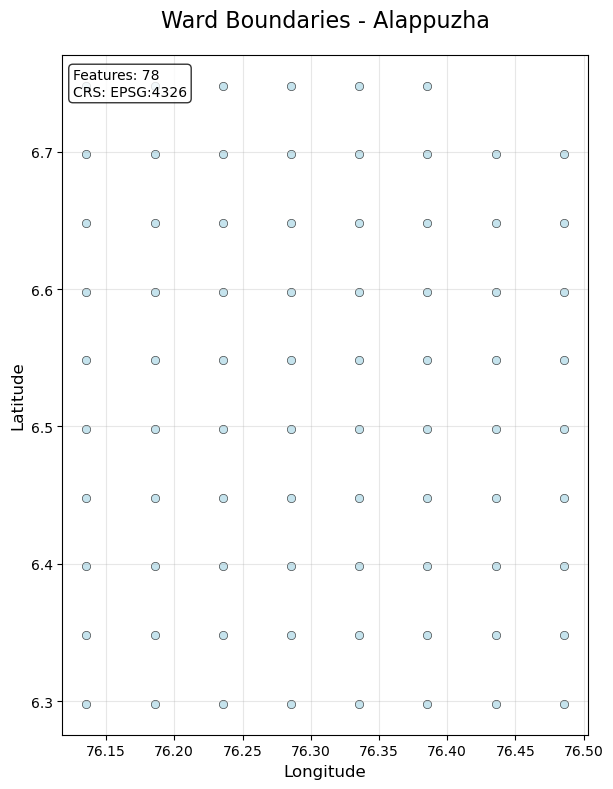

In [4]:
# Visualize a sample district (Alappuzha)
if available_districts:
    sample_district = available_districts[0]  # First district
    print(f"Visualizing sample district: {sample_district}")
    gdf_sample = visualize_shapefile(sample_district)
else:
    print("No districts available for visualization")

Interactive widgets available!


Output()

Loading shapefiles/Alappuzha/Alappuzha.shp...
✓ Loaded 78 features
  CRS: EPSG:4326
  Columns: ['name', 'district', 'html_page', 'id', 'geometry']
  Geometry type: Point

First 5 rows:


,name,district,html_page,id,geometry
0,Alappuzha,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Al...,1,POINT (76.1355 6.2981)
1,Ala,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Al...,2,POINT (76.1855 6.2981)
2,Ambalapuzha North,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Am...,3,POINT (76.2355 6.2981)
3,Ambalapuzha South,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Am...,4,POINT (76.2855 6.2981)
4,Arattupuzha,Alappuzha,https://wardmap.ksmart.live/files/Alappuzha_Ar...,5,POINT (76.3355 6.2981)


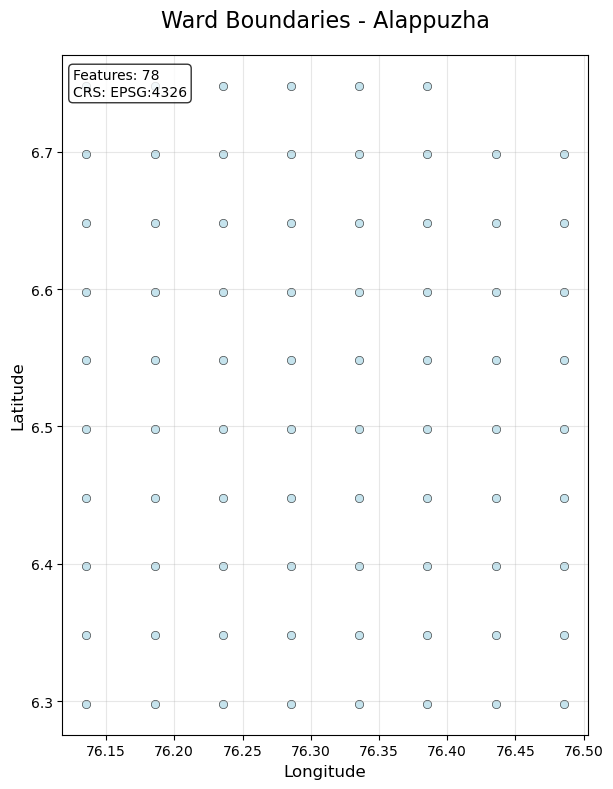

In [5]:
# Interactive visualization (requires ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    
    print("Interactive widgets available!")
    
    # Create dropdown for district selection
    district_dropdown = widgets.Dropdown(
        options=available_districts,
        value=available_districts[0] if available_districts else None,
        description='District:',
        disabled=False,
    )
    
    # Create button to visualize
    visualize_button = widgets.Button(
        description='Visualize',
        button_style='primary',
        tooltip='Click to visualize the selected district',
    )
    
    # Output area
    output_area = widgets.Output()
    
    def on_visualize_button_clicked(b):
        with output_area:
            clear_output(wait=True)
            selected_district = district_dropdown.value
            print(f"Visualizing: {selected_district}")
            gdf = visualize_shapefile(selected_district)
            if gdf is not None:
                print(f"✓ Successfully visualized {selected_district}")
    
    visualize_button.on_click(on_visualize_button_clicked)
    
    # Display widgets
    display(widgets.HBox([district_dropdown, visualize_button]))
    display(output_area)
    
    # Initial visualization
    with output_area:
        gdf = visualize_shapefile(available_districts[0])
        
except ImportError:
    print("ipywidgets not available. Install with: pip install ipywidgets")
    print("For now, you can manually call visualize_shapefile('DistrictName')")